In [7]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

base_path = r"C:\Users\ASUS\Downloads\dk"
input_file = f"{base_path}\\UserBehavior--1.csv"
output_file = f"{base_path}\\UserBehavior_clean.csv"

# 读取原始数据
df = pd.read_csv(input_file, encoding="gb18030", encoding_errors="ignore")
print(f"原始数据总行数：{df.shape[0]}")

# ==========1.删除完全重复整行记录==========
df = df.drop_duplicates(keep="first").reset_index(drop=True)

# ==========2.关键字段缺失删除（核心业务字段不能为空）==========
df = df.dropna(subset=["user_id", "goods_id", "category_id", "behavior"])

# ==========3.其余字段缺失值填充==========
df["sex"] = df["sex"].fillna(-1).astype(int)
df["address"] = df["address"].fillna("未知城市")
df["device"] = df["device"].fillna("未知设备")
df["price"] = df["price"].fillna(0)
df["amount"] = df["amount"].fillna(0)
df["comment"] = df["comment"].fillna("")

# ==========4.过滤合法行为，只保留 pv、fav、cart、buy==========
valid_behavior = ["pv", "fav", "cart", "buy"]
df = df[df["behavior"].isin(valid_behavior)].reset_index(drop=True)

# ==========5.时间戳处理，生成date、hour字段==========
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
df["dt"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")
df["date"] = df["dt"].dt.date
df["hour"] = df["dt"].dt.hour

# ==========6.筛选业务时间窗口：2024‑05‑28 ~ 2024‑06‑04==========
start_date = pd.to_datetime("2024-05-28").date()
end_date = pd.to_datetime("2024-06-04").date()
df = df[(df["date"] >= start_date) & (df["date"] <= end_date)].reset_index(drop=True)

# ==========7.过滤price、amount负数异常数据==========
df = df[(df["price"] >= 0) & (df["amount"] >= 0)].reset_index(drop=True)

# ==========8.输出清洗后的csv文件==========
df.to_csv(output_file, index=False, encoding="utf-8-sig")
print(f"✅清洗完成，清洗后行数：{df.shape[0]}")
print(f"✅文件输出路径：{output_file}")

原始数据总行数：764833
✅清洗完成，清洗后行数：757565
✅文件输出路径：C:\Users\ASUS\Downloads\dk\UserBehavior_clean.csv


In [10]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

file_in = r"C:\Users\ASUS\Downloads\dk\UserBehavior_clean.csv"
file_out = r"C:\Users\ASUS\Downloads\dk\UserBehavior_reclean_outlier.csv"
file_out_filter = r"C:\Users\ASUS\Downloads\dk\UserBehavior_filter_outlier.csv"

# ========== 读取数据 ==========
df = pd.read_csv(file_in, encoding="utf-8-sig")
print(f"📥 原始读取行数：{len(df):,}")

# ========== 第一步：基础清洗（去重 + 缺失值 + 高频用户标记）==========
print("\n" + "="*60)
print("🧹 第一步：基础清洗")
print("="*60)

# 1. 业务主键去重
key_cols = ["user_id", "timestamp", "behavior"]
before = len(df)
df = df.drop_duplicates(subset=key_cols, keep="first")
print(f"业务主键去重：删除 {before - len(df):,} 条")

# 2. comment 填充
df["comment"] = df["comment"].fillna("无评论")

# 3. 核心字段非空校验
core_cols = ["user_id", "goods_id", "category_id", "behavior", "timestamp"]
before = len(df)
df = df.dropna(subset=core_cols)
print(f"核心字段缺失删除：删除 {before - len(df):,} 条")

# 4. 高频用户标记
user_act_cnt = df.groupby("user_id").size()
freq_threshold = user_act_cnt.quantile(0.99)
high_freq_uid = user_act_cnt[user_act_cnt > freq_threshold].index.tolist()
df["is_high_freq"] = df["user_id"].apply(lambda x: 1 if x in high_freq_uid else 0)
print(f"标记超高频用户：{len(high_freq_uid)} 人")

# ========== 第二步：异常值检测与删除 ==========
print("\n" + "="*60)
print("🔍 第二步：异常值检测与删除")
print("="*60)

# ---- 2.1 非下单行为的价格/数量校验 ----
# 正常逻辑：pv/cart/fav 行为的 price 和 amount 应该都是 0
non_buy = df[df["behavior"] != "buy"]
non_buy_price_nonzero = (non_buy["price"] != 0).sum()
non_buy_amount_nonzero = (non_buy["amount"] != 0).sum()

print(f"\n【非下单行为校验】")
print(f"  非下单行数：{len(non_buy):,}")
print(f"  其中 price≠0 的异常行：{non_buy_price_nonzero:,}")
print(f"  其中 amount≠0 的异常行：{non_buy_amount_nonzero:,}")

# 删除非下单行为中 price 或 amount 不为0的异常数据
before = len(df)
mask_nonbuy_outlier = (df["behavior"] != "buy") & ((df["price"] != 0) | (df["amount"] != 0))
df = df[~mask_nonbuy_outlier]
print(f"  删除非下单行为价格/数量异常：{before - len(df):,} 条")

# ---- 2.2 下单行为(buy)的价格异常值检测（IQR方法）----
buy_df = df[df["behavior"] == "buy"].copy()
print(f"\n【下单行为(buy)价格异常检测 - IQR法】")
print(f"  下单总行数：{len(buy_df):,}")

Q1_price = buy_df["price"].quantile(0.25)
Q3_price = buy_df["price"].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

print(f"  Q1={Q1_price:.2f}, Q3={Q3_price:.2f}, IQR={IQR_price:.2f}")
print(f"  正常区间：[{max(lower_price, 0):.2f}, {upper_price:.2f}]")
print(f"  price 范围：[{buy_df['price'].min():.2f}, {buy_df['price'].max():.2f}]")

# 统计价格异常的下单行
buy_price_outlier = buy_df[(buy_df["price"] < max(lower_price, 0)) | (buy_df["price"] > upper_price)]
print(f"  价格异常下单数：{len(buy_price_outlier):,}（占下单 {len(buy_price_outlier)/len(buy_df)*100:.2f}%）")

# ---- 2.3 下单行为(buy)的数量异常值检测（IQR方法）----
Q1_amt = buy_df["amount"].quantile(0.25)
Q3_amt = buy_df["amount"].quantile(0.75)
IQR_amt = Q3_amt - Q1_amt
lower_amt = Q1_amt - 1.5 * IQR_amt
upper_amt = Q3_amt + 1.5 * IQR_amt

print(f"\n【下单行为(buy)数量异常检测 - IQR法】")
print(f"  Q1={Q1_amt:.0f}, Q3={Q3_amt:.0f}, IQR={IQR_amt:.0f}")
print(f"  正常区间：[{max(lower_amt, 0):.0f}, {upper_amt:.0f}]")
print(f"  amount 范围：[{buy_df['amount'].min():.0f}, {buy_df['amount'].max():.0f}]")

buy_amt_outlier = buy_df[(buy_df["amount"] < max(lower_amt, 0)) | (buy_df["amount"] > upper_amt)]
print(f"  数量异常下单数：{len(buy_amt_outlier):,}（占下单 {len(buy_amt_outlier)/len(buy_df)*100:.2f}%）")

# ---- 2.4 执行异常值删除（价格或数量任一异常都删）----
before = len(df)
# 只对 buy 行为做异常值删除
buy_mask_outlier = (
    (df["behavior"] == "buy") & 
    ((df["price"] < max(lower_price, 0)) | (df["price"] > upper_price) |
     (df["amount"] < max(lower_amt, 0)) | (df["amount"] > upper_amt))
)
df = df[~buy_mask_outlier]
print(f"\n  删除下单异常值（价格/数量）：{before - len(df):,} 条")

# ---- 2.5 补充：3σ 法检测（可选，更严格）----
print(f"\n【下单行为(buy)价格异常检测 - 3σ法（参考）】")
mean_price = buy_df["price"].mean()
std_price = buy_df["price"].std()
sigma3_lower = max(mean_price - 3 * std_price, 0)
sigma3_upper = mean_price + 3 * std_price
buy_price_3sigma = buy_df[(buy_df["price"] < sigma3_lower) | (buy_df["price"] > sigma3_upper)]
print(f"  3σ 区间：[{sigma3_lower:.2f}, {sigma3_upper:.2f}]")
print(f"  3σ 异常数：{len(buy_price_3sigma):,}（占下单 {len(buy_price_3sigma)/len(buy_df)*100:.2f}%）")
print("  （3σ法更宽松，异常更少，适合不想删太多数据的场景）")

# ========== 第三步：其他字段异常校验 ==========
print("\n" + "="*60)
print("🔍 第三步：其他字段异常校验")
print("="*60)

# sex 字段校验：应该只有 0 和 1
sex_values = df["sex"].unique()
print(f"\n【sex 字段】取值：{sorted(sex_values)}")
if set(sex_values) <= {0, 1}:
    print("  ✅ sex 取值正常（0/1）")
else:
    abnormal_sex = df[~df["sex"].isin([0, 1])]
    print(f"  ⚠️  存在异常 sex 值，共 {len(abnormal_sex):,} 条")
    df = df[df["sex"].isin([0, 1])]
    print(f"  已删除 {len(abnormal_sex):,} 条")

# hour 字段校验：应该在 0-23 之间
hour_abnormal = df[(df["hour"] < 0) | (df["hour"] > 23)]
print(f"\n【hour 字段】异常值（0-23外）：{len(hour_abnormal):,} 条")
if len(hour_abnormal) > 0:
    df = df[(df["hour"] >= 0) & (df["hour"] <= 23)]
    print(f"  已删除 {len(hour_abnormal):,} 条")
else:
    print("  ✅ hour 取值正常")

# device 字段：查看有哪些取值
print(f"\n【device 字段】取值分布：")
print(df["device"].value_counts())

# ========== 第四步：输出结果 ==========
print("\n" + "="*60)
print("📤 第四步：输出清洗后数据")
print("="*60)

# 完整版（带高频用户标记）
df.to_csv(file_out, index=False, encoding="utf-8-sig")

# 过滤高频用户 + 异常值版本
df_filter = df[df["is_high_freq"] == 0].copy()
df_filter.to_csv(file_out_filter, index=False, encoding="utf-8-sig")

print(f"\n【完整版（含高频标记）】")
print(f"  行数：{len(df):,}")
print(f"  路径：{file_out}")

print(f"\n【过滤版（剔除高频+异常值）】")
print(f"  行数：{len(df_filter):,}")
print(f"  路径：{file_out_filter}")

# ========== 第五步：清洗前后对比 ==========
print("\n" + "="*60)
print("📊 清洗前后对比")
print("="*60)

original = pd.read_csv(file_in, encoding="utf-8-sig")
print(f"\n  原始数据行数：{len(original):,}")
print(f"  清洗后行数：  {len(df):,}")
print(f"  共删除：      {len(original) - len(df):,} 行")
print(f"  删除比例：    {(len(original) - len(df))/len(original)*100:.2f}%")

print(f"\n  原始用户数：  {original['user_id'].nunique():,}")
print(f"  清洗后用户数：{df['user_id'].nunique():,}")

# 行为类型对比
print(f"\n  行为类型分布变化：")
beh_before = original["behavior"].value_counts()
beh_after = df["behavior"].value_counts()
beh_compare = pd.DataFrame({
    "清洗前": beh_before,
    "清洗后": beh_after,
    "删除数": beh_before - beh_after,
    "删除率%": ((beh_before - beh_after) / beh_before * 100).round(2)
})
print(beh_compare)

print("\n✅ 异常值删除完成！")
print("""
💡 使用建议：
1. 做用户分层/转化率 → 用 UserBehavior_filter_outlier.csv（最干净）
2. 做大盘整体统计 → 用 UserBehavior_reclean_outlier.csv（带标记，可分组对比）
3. IQR法删得稍多，3σ法更宽松；如果觉得删太多，可以把 IQR 系数从 1.5 改成 3
""")

📥 原始读取行数：757,565

🧹 第一步：基础清洗
业务主键去重：删除 2,029 条
核心字段缺失删除：删除 0 条
标记超高频用户：107 人

🔍 第二步：异常值检测与删除

【非下单行为校验】
  非下单行数：742,190
  其中 price≠0 的异常行：0
  其中 amount≠0 的异常行：0
  删除非下单行为价格/数量异常：0 条

【下单行为(buy)价格异常检测 - IQR法】
  下单总行数：13,346
  Q1=24.50, Q3=75.00, IQR=50.50
  正常区间：[0.00, 150.75]
  price 范围：[0.00, 99.90]
  价格异常下单数：0（占下单 0.00%）

【下单行为(buy)数量异常检测 - IQR法】
  Q1=1, Q3=4, IQR=3
  正常区间：[0, 8]
  amount 范围：[1, 4]
  数量异常下单数：0（占下单 0.00%）

  删除下单异常值（价格/数量）：0 条

【下单行为(buy)价格异常检测 - 3σ法（参考）】
  3σ 区间：[0.00, 136.63]
  3σ 异常数：0（占下单 0.00%）
  （3σ法更宽松，异常更少，适合不想删太多数据的场景）

🔍 第三步：其他字段异常校验

【sex 字段】取值：[np.int64(0), np.int64(1)]
  ✅ sex 取值正常（0/1）

【hour 字段】异常值（0-23外）：0 条
  ✅ hour 取值正常

【device 字段】取值分布：
device
荣耀        179945
moto       89486
小米         62725
Redmi      60118
魅族         56001
iPhone     55725
OPPO       54137
HUAWEI     53344
vivo       44982
三星         42370
一加         31673
联想         25030
Name: count, dtype: int64

📤 第四步：输出清洗后数据

【完整版（含高频标记）】
  行数：755,536
  路径：C:\Users\ASUS\Downloads\dk\UserBeh

✅ 使用 utf-8-sig 编码读取成功

📊 数据基本信息：
  总行数：716,773 行
  总列数：15 列
  列名：['user_id', 'goods_id', 'category_id', 'behavior', 'timestamp', 'sex', 'address', 'device', 'price', 'amount', 'comment', 'dt', 'date', 'hour', 'is_high_freq']

🔍 【检查1】缺失值检查
Empty DataFrame
Columns: [缺失数量, 缺失占比%]
Index: []
  ✅ 无缺失值，清洗到位

🔍 【检查2】完全重复行检查
  完全重复行数：0 行
  重复占比：0.00%
  ✅ 无完全重复行

  业务主键重复（user_id+timestamp+behavior）：0 行
  ✅ 业务主键无重复

🔍 【检查3】字段类型与取值合理性

📋 各字段数据类型：
user_id           int64
goods_id          int64
category_id       int64
behavior         object
timestamp       float64
sex               int64
address          object
device           object
price           float64
amount            int64
comment          object
dt               object
date             object
hour            float64
is_high_freq      int64
dtype: object

🎯 behavior 行为类型分布：
              数量    占比%
behavior               
pv        643384  89.76
cart       41352   5.77
fav        18966   2.65
buy        13071   1.82
  ✅ 行为类型均在预期范围内

👤 use

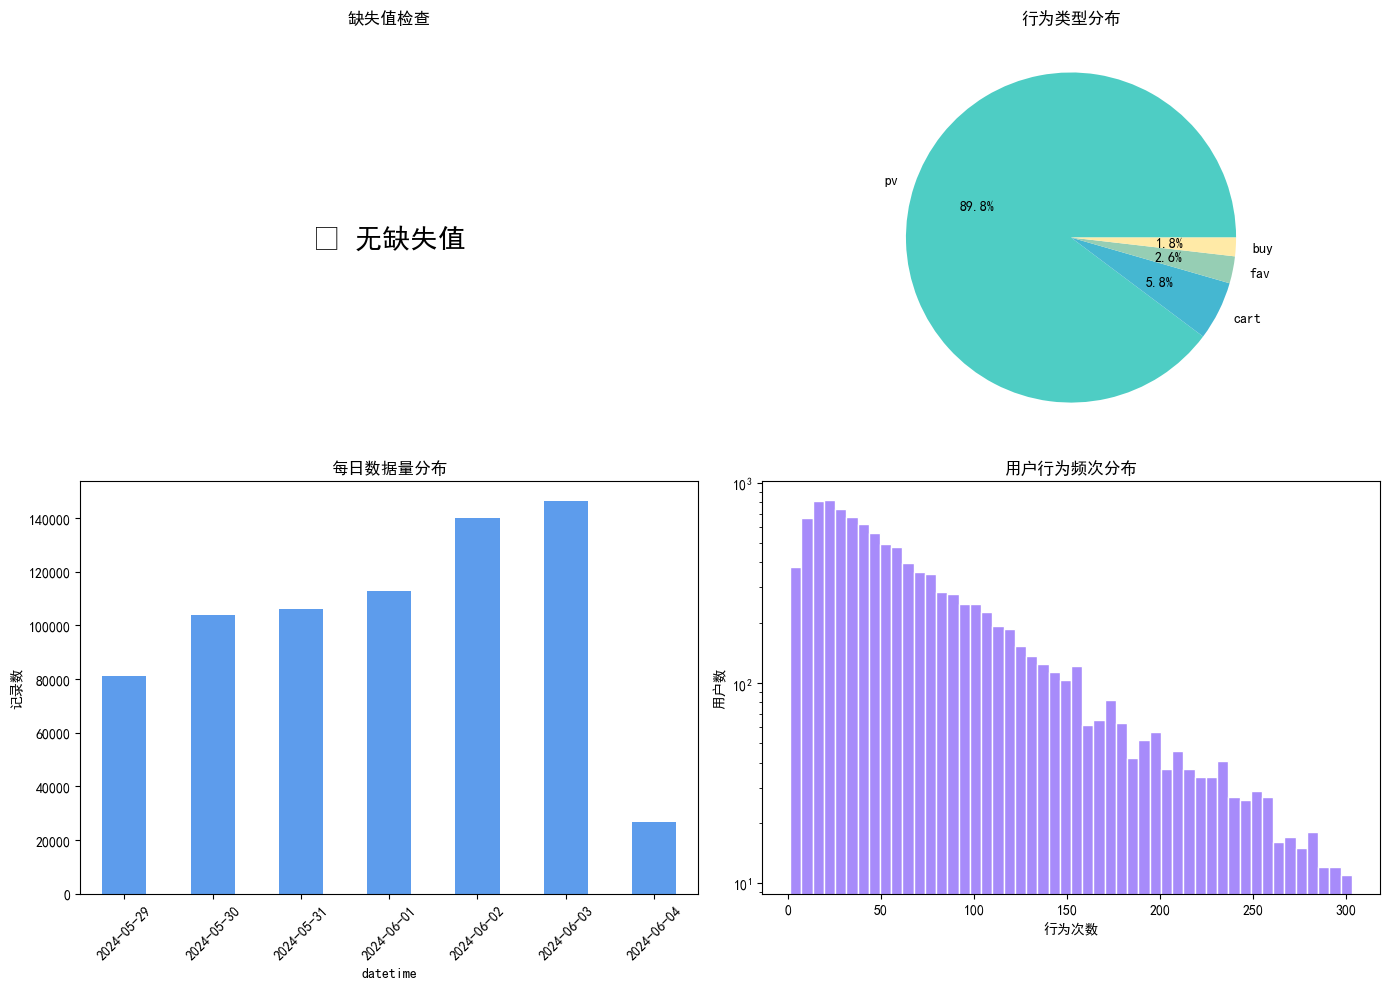


🏆 【清洗质量综合评分】

  综合评分：95.0 / 100

  扣分项：
    ⚠️  异常用户扣 5.0 分

  🟢 评级：优秀 — 可以直接用于分析

✅ 检查完成！


In [13]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# ========== 读取清洗后的数据 ==========
file_path = r"C:\Users\ASUS\Downloads\dk\UserBehavior_filter_outlier.csv"

# 尝试多种编码读取
try:
    df = pd.read_csv(file_path, encoding="utf-8-sig")
    print("✅ 使用 utf-8-sig 编码读取成功")
except:
    try:
        df = pd.read_csv(file_path, encoding="gbk")
        print("✅ 使用 gbk 编码读取成功")
    except Exception as e:
        print(f"❌ 读取失败: {e}")
        raise

print(f"\n📊 数据基本信息：")
print(f"  总行数：{len(df):,} 行")
print(f"  总列数：{len(df.columns)} 列")
print(f"  列名：{list(df.columns)}")

# ========== 1. 缺失值检查 ==========
print("\n" + "="*60)
print("🔍 【检查1】缺失值检查")
print("="*60)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "缺失数量": missing,
    "缺失占比%": missing_pct
}).sort_values("缺失数量", ascending=False)

print(missing_df[missing_df["缺失数量"] > 0])
if missing.sum() == 0:
    print("  ✅ 无缺失值，清洗到位")
else:
    print(f"  ⚠️  共 {missing.sum()} 条缺失记录，占比 {missing.sum()/len(df)*100:.2f}%")

# ========== 2. 重复值检查 ==========
print("\n" + "="*60)
print("🔍 【检查2】完全重复行检查")
print("="*60)

dup_count = df.duplicated().sum()
print(f"  完全重复行数：{dup_count:,} 行")
print(f"  重复占比：{dup_count/len(df)*100:.2f}%")

if dup_count > 0:
    print("  ⚠️  存在完全重复行，建议 drop_duplicates()")
else:
    print("  ✅ 无完全重复行")

# 检查业务主键重复（user_id + item_id + timestamp + behavior）
key_cols = [c for c in ["user_id", "item_id", "timestamp", "behavior"] if c in df.columns]
if len(key_cols) >= 3:
    key_dup = df.duplicated(subset=key_cols).sum()
    print(f"\n  业务主键重复（{'+'.join(key_cols)}）：{key_dup:,} 行")
    if key_dup > 0:
        print("  ⚠️  存在业务重复，可能是日志重复上报")
    else:
        print("  ✅ 业务主键无重复")

# ========== 3. 字段类型与值合理性检查 ==========
print("\n" + "="*60)
print("🔍 【检查3】字段类型与取值合理性")
print("="*60)

print("\n📋 各字段数据类型：")
print(df.dtypes)

# 检查 behavior 字段
if "behavior" in df.columns:
    print("\n🎯 behavior 行为类型分布：")
    beh_counts = df["behavior"].value_counts()
    beh_pct = (beh_counts / len(df) * 100).round(2)
    beh_df = pd.DataFrame({"数量": beh_counts, "占比%": beh_pct})
    print(beh_df)
    
    expected = ["pv", "cart", "buy", "fav"]
    unexpected = [b for b in df["behavior"].unique() if b not in expected]
    if unexpected:
        print(f"  ⚠️  存在异常行为类型：{unexpected}")
    else:
        print("  ✅ 行为类型均在预期范围内")

# 检查 user_id / item_id
for col in ["user_id", "item_id", "category_id"]:
    if col in df.columns:
        n_unique = df[col].nunique()
        print(f"\n👤 {col} 唯一值数量：{n_unique:,}")
        # 检查是否有负值或0
        if pd.api.types.is_numeric_dtype(df[col]):
            neg_count = (df[col] <= 0).sum()
            if neg_count > 0:
                print(f"  ⚠️  存在 {neg_count} 条非正ID值")
            else:
                print(f"  ✅ ID均为正值")

# ========== 4. 时间字段检查 ==========
print("\n" + "="*60)
print("🔍 【检查4】时间字段合理性")
print("="*60)

if "timestamp" in df.columns:
    # 尝试转换时间
    if df["timestamp"].dtype in ['int64', 'float64', 'object']:
        try:
            df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")
            print(f"  时间范围：{df['datetime'].min()} ~ {df['datetime'].max()}")
            print(f"  时间跨度：{df['datetime'].max() - df['datetime'].min()}")
            
            # 检查是否在618大促窗口内
            start = pd.Timestamp("2024-05-28")
            end = pd.Timestamp("2024-06-04 23:59:59")
            out_of_range = ((df["datetime"] < start) | (df["datetime"] > end)).sum()
            print(f"\n  618窗口（5.28-6.4）外的数据：{out_of_range:,} 条")
            if out_of_range > 0:
                print(f"  ⚠️  有 {out_of_range/len(df)*100:.2f}% 数据不在大促时间窗口内")
            else:
                print("  ✅ 全部数据在大促时间窗口内")
            
            # 按天统计
            daily = df.groupby(df["datetime"].dt.date).size()
            print("\n📅 每日数据量：")
            for date, cnt in daily.items():
                bar = "█" * int(cnt / daily.max() * 30)
                print(f"  {date}: {cnt:>10,} {bar}")
                
        except Exception as e:
            print(f"  ⚠️  时间转换失败: {e}")

# ========== 5. 数值型字段异常值检查 ==========
print("\n" + "="*60)
print("🔍 【检查5】数值异常值检查（IQR方法）")
print("="*60)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# 排除ID类字段
id_cols = [c for c in numeric_cols if "id" in c.lower() or "timestamp" in c.lower()]
check_cols = [c for c in numeric_cols if c not in id_cols]

if check_cols:
    for col in check_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        print(f"\n  {col}:")
        print(f"    范围：[{df[col].min():.2f}, {df[col].max():.2f}]")
        print(f"    均值：{df[col].mean():.2f}，中位数：{df[col].median():.2f}")
        print(f"    异常值数量：{outliers:,}（{outliers/len(df)*100:.2f}%）")
else:
    print("  （无非ID类数值字段，跳过异常值检查）")

# ========== 6. 用户行为合理性检查 ==========
print("\n" + "="*60)
print("🔍 【检查6】用户行为合理性（异常用户检测）")
print("="*60)

if "user_id" in df.columns and "behavior" in df.columns:
    user_act_count = df.groupby("user_id").size()
    print(f"  用户平均行为数：{user_act_count.mean():.1f} 次")
    print(f"  用户行为中位数：{user_act_count.median():.1f} 次")
    print(f"  行为最多的用户：{user_act_count.max():,} 次")
    
    # 检测高频用户（可能是爬虫/机器人）
    threshold = user_act_count.quantile(0.99)
    high_freq_users = (user_act_count > threshold).sum()
    print(f"\n  99分位数阈值：{threshold:.0f} 次/人")
    print(f"  超高频用户数（>99分位）：{high_freq_users:,} 人")
    print(f"  这部分用户贡献的行为占比：{user_act_count[user_act_count > threshold].sum() / len(df) * 100:.2f}%")
    
    if high_freq_users > 0:
        print("  ⚠️  存在超高频用户，建议评估是否为异常流量")
    else:
        print("  ✅ 用户行为频次分布正常")

# ========== 7. 可视化：清洗质量总览 ==========
print("\n" + "="*60)
print("📈 【可视化】清洗质量总览图")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图1：缺失值占比
if missing.sum() > 0:
    missing_plot = missing_df[missing_df["缺失数量"] > 0]
    axes[0,0].barh(missing_plot.index, missing_plot["缺失占比%"], color="#ff6b6b")
    axes[0,0].set_title("各字段缺失值占比(%)")
    axes[0,0].set_xlabel("占比%")
else:
    axes[0,0].text(0.5, 0.5, "✅ 无缺失值", ha="center", va="center", fontsize=20, transform=axes[0,0].transAxes)
    axes[0,0].set_title("缺失值检查")
    axes[0,0].axis("off")

# 图2：行为类型分布
if "behavior" in df.columns:
    beh_counts.plot(kind="pie", autopct="%.1f%%", ax=axes[0,1], colors=["#4ECDC4","#45B7D1","#96CEB4","#FFEAA7"])
    axes[0,1].set_title("行为类型分布")
    axes[0,1].set_ylabel("")

# 图3：每日数据量
if "datetime" in df.columns:
    daily.plot(kind="bar", ax=axes[1,0], color="#5D9CEC")
    axes[1,0].set_title("每日数据量分布")
    axes[1,0].set_ylabel("记录数")
    axes[1,0].tick_params(axis="x", rotation=45)

# 图4：用户行为频次分布（对数坐标）
if "user_id" in df.columns:
    axes[1,1].hist(user_act_count, bins=50, color="#A78BFA", edgecolor="white")
    axes[1,1].set_title("用户行为频次分布")
    axes[1,1].set_xlabel("行为次数")
    axes[1,1].set_ylabel("用户数")
    axes[1,1].set_yscale("log")

plt.tight_layout()
output_path = r"C:\Users\ASUS\Downloads\dk\清洗质量检查报告.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"  ✅ 可视化报告已保存：{output_path}")
plt.show()

# ========== 8. 清洗质量评分 ==========
print("\n" + "="*60)
print("🏆 【清洗质量综合评分】")
print("="*60)

score = 100
issues = []

# 扣分规则
if missing.sum() > 0:
    deduction = min(missing.sum()/len(df)*100 * 2, 20)
    score -= deduction
    issues.append(f"⚠️  缺失值扣 {deduction:.1f} 分")
if dup_count > 0:
    deduction = min(dup_count/len(df)*100 * 3, 15)
    score -= deduction
    issues.append(f"⚠️  重复值扣 {deduction:.1f} 分")
if "timestamp" in df.columns and out_of_range > 0:
    deduction = min(out_of_range/len(df)*100 * 2, 10)
    score -= deduction
    issues.append(f"⚠️  时间越界扣 {deduction:.1f} 分")
if "user_id" in df.columns and high_freq_users > 0:
    deduction = 5
    score -= deduction
    issues.append(f"⚠️  异常用户扣 {deduction:.1f} 分")

print(f"\n  综合评分：{max(score, 0):.1f} / 100")
if issues:
    print("\n  扣分项：")
    for issue in issues:
        print(f"    {issue}")
else:
    print("  ✅ 各项检查均通过，清洗质量优秀！")

if score >= 90:
    print("\n  🟢 评级：优秀 — 可以直接用于分析")
elif score >= 75:
    print("\n  🟡 评级：良好 — 小问题，基本可用")
elif score >= 60:
    print("\n  🟠 评级：及格 — 建议补充清洗后再分析")
else:
    print("\n  🔴 评级：待改进 — 需要重新清洗")

print("\n" + "="*60)
print("✅ 检查完成！")
print("="*60)